In [1]:
from evaluation.post_run_analysis import run_final_evaluation_and_visualization
from model.architecture import GuitarTabCRNN, TabCNN
from model.utils import load_best_model
import os
import json
import torch
import training
from IPython.display import display, Markdown
from torch.utils.data import DataLoader
from IPython.display import clear_output
import config
from training.pipeline import process_single_hyperparameter_run
from data_processing import preparation, batching, dataset
from vizualization import plotting

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_HOME = config.DATA_HOME_DEFAULT
OUTPUT_BASE_DIR = config.OUTPUT_BASE_DIR_DEFAULT
SEARCH_RUN_NAME = "hyperparam_set_v1"
MAIN_SEARCH_ARTIFACTS_DIR = os.path.join(OUTPUT_BASE_DIR, SEARCH_RUN_NAME)

os.makedirs(DATA_HOME, exist_ok=True)
os.makedirs(OUTPUT_BASE_DIR, exist_ok=True)
os.makedirs(MAIN_SEARCH_ARTIFACTS_DIR, exist_ok=True)

print(f"Using DATA_HOME: {DATA_HOME}")
print(f"Using OUTPUT_BASE_DIR: {OUTPUT_BASE_DIR}")
print(f"Using MAIN_SEARCH_ARTIFACTS_DIR: {MAIN_SEARCH_ARTIFACTS_DIR}")

param_grid = []
try:
    with open(config.DEFAULT_HYPERPARAMETER_FILE, "r", encoding="utf-8") as f:
        param_grid = json.load(f)
    print(
        f"Loaded {len(param_grid)} hyperparameter configurations from: "
        f"{config.DEFAULT_HYPERPARAMETER_FILE}"
    )
    if param_grid:
        print(f"Example of the first loaded configuration: {param_grid[0]}")
except FileNotFoundError:
    print(
        f"ERROR: Hyperparameter configuration file "
        f"'{config.DEFAULT_HYPERPARAMETER_FILE}' was not found."
    )
except json.JSONDecodeError as e_json:
    print(
        f"ERROR: File '{config.DEFAULT_HYPERPARAMETER_FILE}' contains invalid JSON. "
        f"Details: {e_json}"
    )
except Exception as e:
    print(f"ERROR while loading hyperparameter configurations: {e}")

if not param_grid:
    print(
        "WARNING: `param_grid` is empty. Hyperparameter search may not run correctly."
    )

def jupyter_notebook_clear_output(wait=True):
    if config.CLEAR_CONSOLE_EVERY_N_RUNS > 0:
        clear_output(wait=wait)
    else:
        pass

c:\Users\Lenovo\anaconda3\envs\amt_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using DATA_HOME: c:\Users\Lenovo\OneDrive\Desktop\New folder\guitar_music_transcription\python\_mir_datasets_storage
Using OUTPUT_BASE_DIR: c:\Users\Lenovo\OneDrive\Desktop\New folder\guitar_music_transcription\python\_processed_guitarset_data
Using MAIN_SEARCH_ARTIFACTS_DIR: c:\Users\Lenovo\OneDrive\Desktop\New folder\guitar_music_transcription\python\_processed_guitarset_data\hyperparam_set_v1
Loaded 5 hyperparameter configurations from: hyperparam_set_v1.json
Example of the first loaded configuration: {'run_description': 'Baseline_run72_re-run_with_new_aug', 'LEARNING_RATE_INIT': 0.0003, 'ONSET_LOSS_WEIGHT': 9.0, 'ONSET_POS_WEIGHT_MANUAL_VALUE': 6.0, 'RNN_TYPE': 'GRU', 'RNN_HIDDEN_SIZE': 768, 'RNN_LAYERS': 2, 'RNN_DROPOUT': 0.5, 'RNN_BIDIRECTIONAL': True, 'WEIGHT_DECAY': 0.0001, 'SCHEDULER_PATIENCE': 10, 'SCHEDULER_FACTOR': 0.2}


In [2]:
print("--- Step 1: Data Preparation and Splitting ---")
track_ids_map_split = preparation.prepare_track_splits(
    data_home=DATA_HOME,
    problematic_files_list=config.PROBLEMATIC_FILES,
    test_split_fraction=config.TEST_SPLIT_SIZE,
    validation_split_fraction=config.VALIDATION_SPLIT_SIZE,
    seed=config.RANDOM_SEED,
    output_dir_for_ids=OUTPUT_BASE_DIR
)

if any(len(ids) > 0 for ids in track_ids_map_split.values()):
    print("\nStarting GuitarSet preprocessing (existing files will be skipped)...")
    preparation.preprocess_guitarset_data(
        guitarset_data_home=DATA_HOME,
        processed_output_base_dir=OUTPUT_BASE_DIR,
        track_ids_map=track_ids_map_split,
        audio_sample_rate=config.SAMPLE_RATE,
        audio_hop_length=config.HOP_LENGTH,
        audio_n_cqt_bins=config.N_BINS_CQT,
        audio_cqt_bins_per_octave=config.BINS_PER_OCTAVE_CQT,
        audio_cqt_fmin=config.FMIN_CQT
    )
    print("Preprocessing completed or files already existed.")
else:
    print("No tracks available for processing. Preprocessing was not started.")

--- Step 1: Data Preparation and Splitting ---


c:\Users\Lenovo\anaconda3\envs\amt_env\lib\site-packages\google\api_core\_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Found 360 total track IDs in GuitarSet.
Number of track IDs after removing problematic files: 358

Dataset split:
  Training: 286 tracks
  Validation: 36 tracks
  Test: 36 tracks

Saved track ID lists for each split in: c:\Users\Lenovo\OneDrive\Desktop\New folder\guitar_music_transcription\python\_processed_guitarset_data

Starting GuitarSet preprocessing (existing files will be skipped)...
Starting GuitarSet preprocessing.
Dataset directory (guitarset_data_home): c:\Users\Lenovo\OneDrive\Desktop\New folder\guitar_music_transcription\python\_mir_datasets_storage
Output directory (processed_output_base_dir): c:\Users\Lenovo\OneDrive\Desktop\New folder\guitar_music_transcription\python\_processed_guitarset_data

Processing train split (286 tracks)


Processing train: 100%|██████████| 286/286 [00:00<00:00, 3141.44track/s]




Processing validation split (36 tracks)


Processing validation: 100%|██████████| 36/36 [00:00<00:00, 3888.92track/s]




Processing test split (36 tracks)


Processing test: 100%|██████████| 36/36 [00:00<00:00, 2504.93track/s]



--- Preprocessing Summary ---
Total tracks scheduled for processing: 358
  Train split:
    Newly processed: 0
    Skipped (already existed): 286
    Errors: 0
  Validation split:
    Newly processed: 0
    Skipped (already existed): 36
    Errors: 0
  Test split:
    Newly processed: 0
    Skipped (already existed): 36
    Errors: 0
Processed data has been saved to: c:\Users\Lenovo\OneDrive\Desktop\New folder\guitar_music_transcription\python\_processed_guitarset_data
Preprocessing completed or files already existed.


In [3]:
print("\n--- Step 2: Creating Datasets and DataLoaders ---")

train_dataset, validation_dataset, test_dataset = None, None, None
train_dataloader, validation_dataloader, test_dataloader = None, None, None

train_dataset_constructor_params = {
    **config.DATASET_COMMON_PARAMS,
    **config.DATASET_TRAIN_AUGMENTATION_PARAMS,
    "label_transform_function": dataset.create_frame_level_labels,
    "guitarset_data_home": DATA_HOME
}

eval_dataset_constructor_params = {
    **config.DATASET_COMMON_PARAMS,
    **config.DATASET_EVAL_AUGMENTATION_PARAMS,
    "label_transform_function": dataset.create_frame_level_labels,
    "guitarset_data_home": DATA_HOME
}

if track_ids_map_split.get('train') and len(track_ids_map_split['train']) > 0:
    train_dataset = dataset.GuitarSetTabDataset(
        processed_data_base_dir=OUTPUT_BASE_DIR,
        data_split_name='train',
        **train_dataset_constructor_params
    )
    if len(train_dataset) > 0:
        train_dataloader = DataLoader(
            train_dataset,
            batch_size=config.BATCH_SIZE_DEFAULT,
            shuffle=True,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
            collate_fn=batching.collate_fn_pad
        )
        print(f"Created training dataset: {len(train_dataset)} samples, DataLoader ready.")
    else:
        print("Training dataset is empty.")

if track_ids_map_split.get('validation') and len(track_ids_map_split['validation']) > 0:
    validation_dataset = dataset.GuitarSetTabDataset(
        processed_data_base_dir=OUTPUT_BASE_DIR,
        data_split_name='validation',
        **eval_dataset_constructor_params
    )
    if len(validation_dataset) > 0:
        validation_dataloader = DataLoader(
            validation_dataset,
            batch_size=config.BATCH_SIZE_DEFAULT,
            shuffle=False,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
            collate_fn=batching.collate_fn_pad
        )
        print(f"Created validation dataset: {len(validation_dataset)} samples, DataLoader ready.")
    else:
        print("Validation dataset is empty.")

if track_ids_map_split.get('test') and len(track_ids_map_split['test']) > 0:
    test_dataset = dataset.GuitarSetTabDataset(
        processed_data_base_dir=OUTPUT_BASE_DIR,
        data_split_name='test',
        **eval_dataset_constructor_params
    )
    if len(test_dataset) > 0:
        test_dataloader = DataLoader(
            test_dataset,
            batch_size=config.BATCH_SIZE_DEFAULT,
            shuffle=False,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
            collate_fn=batching.collate_fn_pad
        )
        print(f"Created test dataset: {len(test_dataset)} samples, DataLoader ready.")
    else:
        print("Test dataset is empty.")


--- Step 2: Creating Datasets and DataLoaders ---
Created training dataset: 286 samples, DataLoader ready.
Created validation dataset: 36 samples, DataLoader ready.
Created test dataset: 36 samples, DataLoader ready.


--- Step 3: Data Sample Visualization (without augmentation) ---
Validation dataset selected for visualization.
Visualizing sample: 01_Rock3-148-C_solo (index: 0)


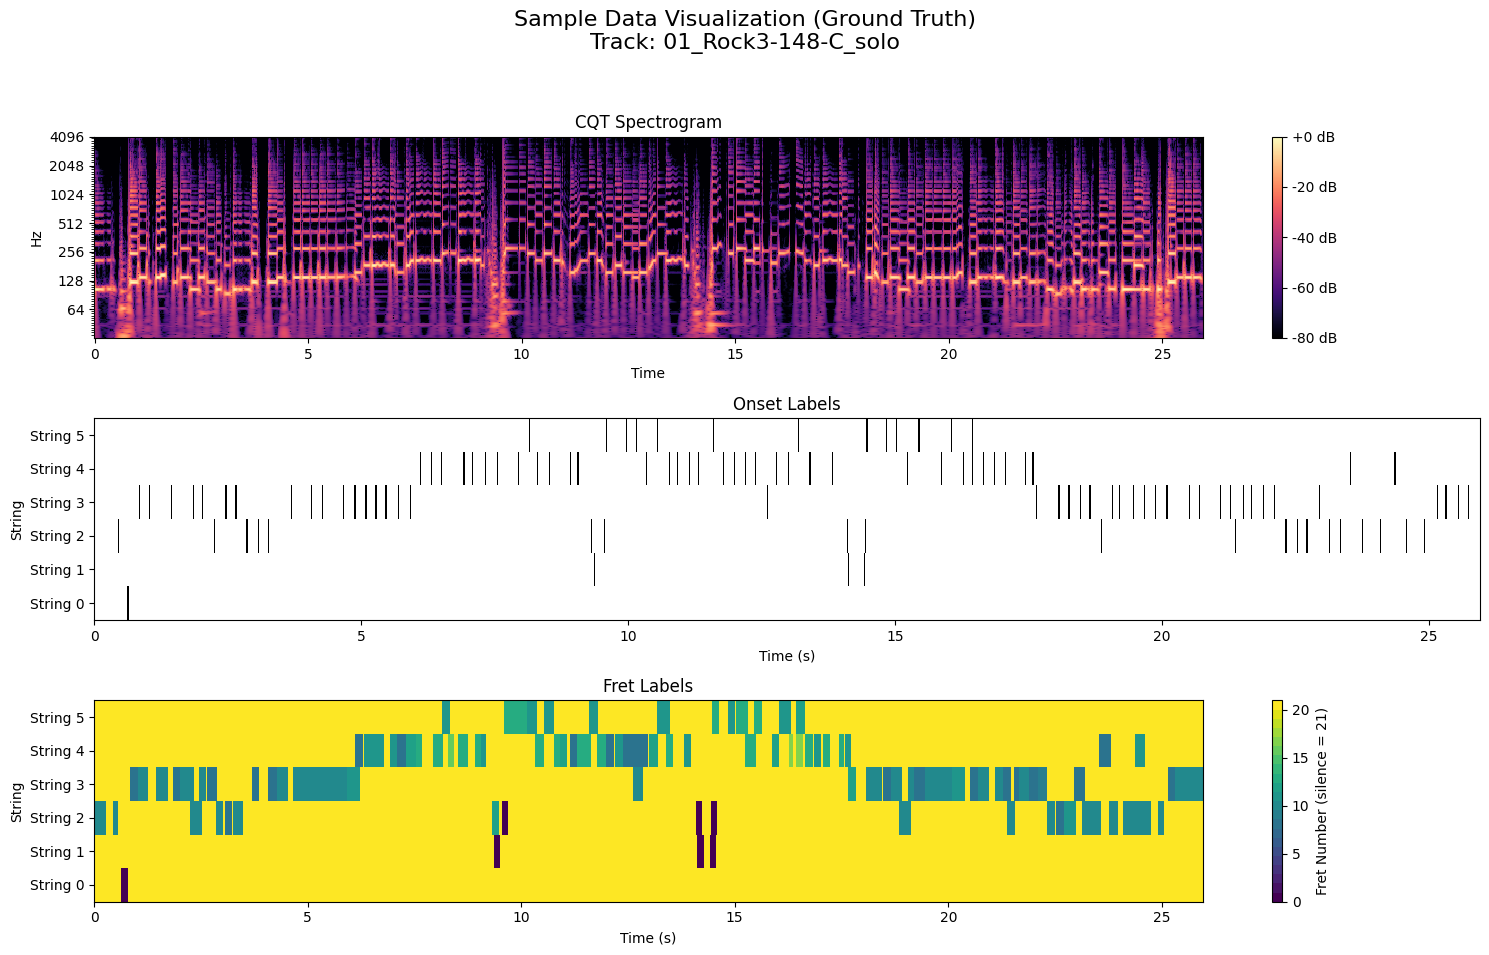

In [4]:
print("--- Step 3: Data Sample Visualization (without augmentation) ---")

dataset_to_visualize = validation_dataset
if dataset_to_visualize and len(dataset_to_visualize) > 0:
    print("Validation dataset selected for visualization.")
    sample_idx_to_plot = 0

    try:
        features, (onset_targets, fret_targets), raw_labels, track_id = dataset_to_visualize[sample_idx_to_plot]
        print(f"Visualizing sample: {track_id} (index: {sample_idx_to_plot})")
        plotting.plot_sample_data_summary(
            features_tensor=features,
            onset_labels_tensor=onset_targets,
            fret_labels_tensor=fret_targets,
            sampling_rate=config.SAMPLE_RATE,
            hop_len=config.HOP_LENGTH,
            track_id_display=track_id
        )
    except Exception as e:
        print(f"An error occurred during data visualization: {e}")
else:
    print("Dataset for visualization is empty or unavailable.")

In [ ]:
def find_next_run_number(artifacts_dir):
    highest_existing_run = 0
    if os.path.exists(artifacts_dir):
        for item in os.listdir(artifacts_dir):
            if os.path.isdir(os.path.join(artifacts_dir, item)) and item.startswith("run_"):
                try:
                    run_num = int(item.split('_')[1])
                    if run_num > highest_existing_run:
                        highest_existing_run = run_num
                except (IndexError, ValueError):
                    continue
    return highest_existing_run + 1


def display_run_summary(summary_file_path, metric_to_sort_by, num_top_to_show=5):
    if not os.path.exists(summary_file_path):
        print(f"Warning: Summary file '{summary_file_path}' does not exist.")
        return

    all_runs = []
    with open(summary_file_path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                all_runs.append(json.loads(line))
            except json.JSONDecodeError:
                continue

    if not all_runs:
        print("No saved runs available for display.")
        return

    def get_sortable_value(result_dict):
        primary_metric_val = result_dict.get(metric_to_sort_by, 0.0)
        test_metrics = result_dict.get("test_metrics_at_0.5", {})
        secondary_metric_val = test_metrics.get("tdr_f1", 0.0) if isinstance(test_metrics, dict) else 0.0
        return (primary_metric_val, secondary_metric_val)

    completed_runs = sorted(
        [run for run in all_runs if run.get("status") == "COMPLETED"],
        key=get_sortable_value,
        reverse=True
    )
    error_runs = [run for run in all_runs if run.get("status") != "COMPLETED"]

    print("\n" + "=" * 25 + " RUN SUMMARY " + "=" * 25)

    print(f"\n--- Best Runs (Top {min(num_top_to_show, len(completed_runs))}) ---")
    for i, summary in enumerate(completed_runs[:num_top_to_show]):
        print(
            f"\nRank {i + 1}: Run {summary.get('run_index', 'N/A')} "
            f"(Folder: {summary.get('run_folder_name', 'N/A')})"
        )
        print(
            f"  - Best validation result ({metric_to_sort_by}): "
            f"{summary.get(metric_to_sort_by, 0.0):.4f}"
        )

        test_metrics = summary.get("test_metrics_at_0.5", {})
        if isinstance(test_metrics, dict) and test_metrics:
            tdr_f1 = test_metrics.get("tdr_f1", 0)
            mpe_f1 = test_metrics.get("mpe_f1", 0)
            onset_f1 = test_metrics.get("onset_f1_event", 0)
            print(
                f"  - Test metrics (thr=0.5): "
                f"TDR F1: {tdr_f1:.4f} | "
                f"MPE F1: {mpe_f1:.4f} | "
                f"Onset F1: {onset_f1:.4f}"
            )
        else:
            print("  - No test metrics available.")

        print(f"  - Stopped at epoch: {summary.get('stopped_epoch', 0)}")
        print(f"  - Parameters: {summary.get('params_combo', {})}")

    if error_runs:
        print("\n--- Failed Runs ---")
        for summary in error_runs:
            print(
                f"\nRun {summary.get('run_index', 'N/A')} "
                f"(Folder: {summary.get('run_folder_name', 'N/A')})"
            )
            print(f"  - Status: {summary.get('status', 'N/A')}")
            print(f"  - Error: {summary.get('error', 'No details')}")
            print(f"  - Parameters: {summary.get('params_combo', {})}")


print(f"{'=' * 20} STARTING HYPERPARAMETER SEARCH {'=' * 20}")

MAIN_SEARCH_ARTIFACTS_DIR = r"C:\Users\Lenovo\OneDrive\Desktop\New folder\guitar_music_transcription\python\results\hyperparam_search"
SUMMARY_FILE_PATH = os.path.join(MAIN_SEARCH_ARTIFACTS_DIR, "hyperparameter_search_summary.jsonl")
current_active_augmentation_params = config.DATASET_TRAIN_AUGMENTATION_PARAMS

os.makedirs(MAIN_SEARCH_ARTIFACTS_DIR, exist_ok=True)
print(f"Main search artifacts directory: {MAIN_SEARCH_ARTIFACTS_DIR}")

if not param_grid:
    print("CRITICAL ERROR: `param_grid` is empty.")
else:
    next_run_start_number = find_next_run_number(MAIN_SEARCH_ARTIFACTS_DIR)
    print(f"New runs will start from number (ID): {next_run_start_number}")

    for run_idx, hyperparams in enumerate(param_grid):
        if (
            run_idx > 0
            and config.CLEAR_CONSOLE_EVERY_N_RUNS > 0
            and run_idx % config.CLEAR_CONSOLE_EVERY_N_RUNS == 0
        ):
            clear_output(wait=True)
            print(
                f"Console output cleared. "
                f"Continuing from run {run_idx + 1}/{len(param_grid)}..."
            )

        run_global_id = next_run_start_number + run_idx

        print(
            f"\n\n{'=' * 30} STARTING RUN "
            f"{run_idx + 1}/{len(param_grid)} "
            f"(Global ID: {run_global_id}) {'=' * 30}"
        )
        print(f"Used hyperparameters: {hyperparams}")

        summary = training.pipeline.process_single_hyperparameter_run(
            run_id=run_global_id,
            hyperparams_combo=hyperparams,
            current_augmentation_params=current_active_augmentation_params,
            config_obj=config,
            main_artifacts_dir=MAIN_SEARCH_ARTIFACTS_DIR,
            train_loader=train_dataloader,
            validation_loader=validation_dataloader,
            test_loader=test_dataloader,
        )

        with open(SUMMARY_FILE_PATH, "a", encoding="utf-8") as f:
            f.write(json.dumps(summary) + "\n")

        print(
            f"\n{'=' * 30} FINISHED RUN "
            f"{run_idx + 1}/{len(param_grid)} "
            f"(ID: {run_global_id}) - "
            f"Status: {summary.get('status', 'UNKNOWN')} "
            f"{'=' * 30}\n"
        )

    display_run_summary(
        SUMMARY_FILE_PATH,
        f"best_{config.CHECKPOINT_METRIC_DEFAULT}"
    )

In [5]:
import os
import json
import torch
from IPython.display import display, Markdown

MAIN_SEARCH_ARTIFACTS_DIR = os.path.join(config.BASE_PROJECT_DIR, "results", "hyperparam_search")

if 'test_dataset' not in locals() or test_dataset is None:
    print("ERROR: Variable 'test_dataset' is not available.")
else:
    available_runs = [
        d for d in os.listdir(MAIN_SEARCH_ARTIFACTS_DIR)
        if d.startswith("run_") and os.path.exists(
            os.path.join(MAIN_SEARCH_ARTIFACTS_DIR, d, "best_model.pth")
        )
    ]

    if not available_runs:
        print(f"No folders with saved models found in '{MAIN_SEARCH_ARTIFACTS_DIR}'")
    else:
        for idx, name in enumerate(available_runs):
            print(f"[{idx + 1}] {name}")

        selected_run_folder_name = None
        while True:
            try:
                choice = int(
                    input(
                        f"\nSelect run number (1-{len(available_runs)}) "
                        "or '0' to skip: "
                    )
                )
                if 0 <= choice <= len(available_runs):
                    if choice > 0:
                        selected_run_folder_name = available_runs[choice - 1]
                    break
                else:
                    print("Invalid selection.")
            except ValueError:
                print("Invalid input, please enter a number.")

    if selected_run_folder_name:
        display(Markdown(f"## Final Evaluation for: `{selected_run_folder_name}`"))

        run_dir = os.path.join(MAIN_SEARCH_ARTIFACTS_DIR, selected_run_folder_name)
        config_path = os.path.join(run_dir, "run_configuration.json")
        model_path = os.path.join(run_dir, "best_model.pth")

        if not os.path.exists(config_path):
            raise FileNotFoundError(f"Configuration file missing in {run_dir}.")

        loaded_model = load_best_model(
            model_class=GuitarTabCRNN,
            model_path=model_path,
            run_config_path=config_path,
            device=device
        )

        if loaded_model is None:
            raise RuntimeError("Failed to load the model.")

        output_dir_for_viz = os.path.join(
            run_dir,
            "final_test_evaluation_tdr_optimized"
        )

        final_metrics, sorted_file_scores = run_final_evaluation_and_visualization(
            model=loaded_model,
            test_dataloader=test_dataloader,
            device=device,
            config_obj=config,
            output_dir=output_dir_for_viz,
            num_top_bottom_files_to_show=3
        )

        if final_metrics:
            print("\n" + "=" * 50)
            print("--- COMPLETE EVALUATION SUMMARY ---")
            print("=" * 50)

            display(Markdown(f"**Run:** `{selected_run_folder_name}`"))

            print("\n**Average Metrics on the Entire Test Set:**")

            print(
                f"  TDR F1-Score: {final_metrics.get('tdr_f1', 0):.4f} | "
                f"TDR Precision: {final_metrics.get('tdr_precision', 0):.4f} | "
                f"TDR Recall: {final_metrics.get('tdr_recall', 0):.4f}"
            )

            print(
                f"  MPE F1-Score: {final_metrics.get('mpe_f1', 0):.4f} | "
                f"MPE Precision: {final_metrics.get('mpe_precision', 0):.4f} | "
                f"MPE Recall: {final_metrics.get('mpe_recall', 0):.4f}"
            )

            print(
                f"  Onset Event F1: {final_metrics.get('onset_f1_event', 0):.4f} | "
                f"Onset Precision: {final_metrics.get('onset_precision_event', 0):.4f} | "
                f"Onset Recall: {final_metrics.get('onset_recall_event', 0):.4f}"
            )

            print(
                "\n**File Ranking "
                "(full list available in .txt files in the artifacts directory):**"
            )
        else:
            print(
                "\nEvaluation failed and did not return metrics. "
                "Check the error messages above."
            )

    else:
        print("\nEvaluation skipped.")

[1] run_1_Baseline_run72_re-run_with_new_aug_augEnabled


## Final Evaluation for: `run_1_Baseline_run72_re-run_with_new_aug_augEnabled`

--- Attempting to load model from file: best_model.pth ---
Reconstructed model initialization parameters: {'num_frames_rnn_input_dim': 1280, 'rnn_type': 'GRU', 'rnn_hidden_size': 768, 'rnn_layers': 2, 'rnn_dropout': 0.5, 'rnn_bidirectional': True, 'cnn_input_channels': 1}
Loading model weights onto device: cuda
Model successfully loaded and moved to device: cuda
Step 1/5: Collecting predictions and labels from the entire test set...


Processing test dataset: 100%|██████████| 18/18 [00:12<00:00,  1.42it/s]


Step 2/5: Searching for the optimal TDR threshold...


Optimizing TDR threshold: 100%|██████████| 91/91 [03:13<00:00,  2.13s/it]


Optimal TDR threshold found: 0.5100
Step 3/5: Computing per-file metrics to create a ranking...
Step 4/5: Computing final averaged metrics...
Step 5/5: Generating tablature files for the best and worst predictions...

--- Top 3 Results (Highest TDR F1) ---
  - File: 04_BN1-147-Gb_comp, F1 Score: 0.9674
  - File: 02_Jazz1-200-B_solo, F1 Score: 0.9647
  - File: 05_Rock3-148-C_solo, F1 Score: 0.9587

--- Bottom 3 Results (Lowest TDR F1) ---
  - File: 01_Funk3-98-A_comp, F1 Score: 0.7093
  - File: 05_SS3-84-Bb_comp, F1 Score: 0.7072
  - File: 04_SS3-98-C_comp, F1 Score: 0.7041

Done. Tablature files have been saved to: c:\Users\Lenovo\OneDrive\Desktop\New folder\guitar_music_transcription\python\results\hyperparam_search\run_1_Baseline_run72_re-run_with_new_aug_augEnabled\final_test_evaluation_tdr_optimized

--- COMPLETE EVALUATION SUMMARY ---


**Run:** `run_1_Baseline_run72_re-run_with_new_aug_augEnabled`


**Average Metrics on the Entire Test Set:**
  TDR F1-Score: 0.8482 | TDR Precision: 0.8846 | TDR Recall: 0.8192
  MPE F1-Score: 0.8663 | MPE Precision: 0.8816 | MPE Recall: 0.8516
  Onset Event F1: 0.8001 | Onset Precision: 0.9549 | Onset Recall: 0.7165

**File Ranking (full list available in .txt files in the artifacts directory):**


In [ ]:
import os
import torch
from IPython.display import display, Markdown
import config
from predict_on_custom import run_custom_prediction

MAIN_SEARCH_ARTIFACTS_DIR = os.path.join(os.getcwd(), "results", "hyperparam_search")
CUSTOM_AUDIO_DIR = os.path.join(os.getcwd(), "test2")

os.makedirs(CUSTOM_AUDIO_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

display(Markdown("## Cell 7: Prediction on Custom Recordings"))
display(Markdown(f"""
Starting custom inference process...
- **Models Directory**: `{MAIN_SEARCH_ARTIFACTS_DIR}`
- **Audio Directory**: `{CUSTOM_AUDIO_DIR}`
- **Device**: `{device}`
"""))

run_custom_prediction(
    artifacts_dir=MAIN_SEARCH_ARTIFACTS_DIR,
    audio_dir=CUSTOM_AUDIO_DIR,
    device=device
)

## Cell 7: Prediction on Custom Recordings


Starting custom inference process...
- **Models Directory**: `c:\Users\Lenovo\OneDrive\Desktop\New folder\guitar_music_transcription\python\results\hyperparam_search`
- **Audio Directory**: `c:\Users\Lenovo\OneDrive\Desktop\New folder\guitar_music_transcription\python\test2`
- **Device**: `cuda`



INITIALIZING CUSTOM INFERENCE PIPELINE
Targeting model directory: run_1_Baseline_run72_re-run_with_new_aug_augEnabled
--- Attempting to load model from file: best_model.pth ---
Reconstructed model initialization parameters: {'num_frames_rnn_input_dim': 1280, 'rnn_type': 'GRU', 'rnn_hidden_size': 768, 'rnn_layers': 2, 'rnn_dropout': 0.5, 'rnn_bidirectional': True, 'cnn_input_channels': 1}
Loading model weights onto device: cuda
Model successfully loaded and moved to device: cuda
Found 1 custom audio tracks for processing.

Transcribing: 2026.08.03-00.59.25-am.mp3...
Loading and resampling audio: 2026.08.03-00.59.25-am.mp3
Computing Constant-Q Transform (CQT)...
Success! Prediction array saved to: c:\Users\Lenovo\OneDrive\Desktop\New folder\guitar_music_transcription\python\test2\transcriptions\2026.08.03-00.59.25-am_prediction.npy

CUSTOM INFERENCE COMPLETE


In [ ]:
import numpy as np
import config

prediction_path = r"c:\Users\Lenovo\OneDrive\Desktop\New folder\guitar_music_transcription\python\test2\transcriptions\2026.08.03-00.59.25-am_prediction.npy"

print("--- DECODING RAW TENSOR TO TABLATURE ---")
binary_tdr = np.load(prediction_path)

string_names = ['E', 'A', 'D', 'G', 'B', 'e']
frame_duration = config.HOP_LENGTH / config.SAMPLE_RATE

silence_fret_index = binary_tdr.shape[2] - 1 

active_frames = 0
for frame_idx in range(binary_tdr.shape[0]):
    active_strings, active_frets = np.where(binary_tdr[frame_idx] == 1)
    
    if len(active_strings) > 0:
        time_sec = frame_idx * frame_duration
        notes_played = []
        
        processed_strings = set()
        
        for string_idx, fret in zip(active_strings, active_frets):
            if fret != silence_fret_index and string_idx not in processed_strings:
                notes_played.append(f"String {string_names[string_idx]}, Fret {fret}")
                processed_strings.add(string_idx)
                
        if notes_played:
            print(f"Time {time_sec:.2f}s | Notes detected: {', '.join(notes_played)}")
            active_frames += 1
            
        if active_frames >= 25:
            print(f"... and {binary_tdr.shape[0] - frame_idx} more frames of transcribed audio.")
            break

if active_frames == 0:
    print("No notes detected. The threshold might be set too high.")

--- DECODING RAW TENSOR TO TABLATURE ---
Time 0.00s | Notes detected: String E, Fret 0, String D, Fret 0, String G, Fret 5, String B, Fret 4
Time 0.02s | Notes detected: String E, Fret 0, String A, Fret 3, String D, Fret 0, String G, Fret 4, String B, Fret 1, String e, Fret 8
Time 0.05s | Notes detected: String E, Fret 0, String A, Fret 0, String D, Fret 0, String G, Fret 4, String B, Fret 1, String e, Fret 8
Time 0.07s | Notes detected: String E, Fret 1, String A, Fret 0, String D, Fret 0, String G, Fret 5, String B, Fret 1, String e, Fret 8
Time 0.09s | Notes detected: String E, Fret 1, String A, Fret 0, String D, Fret 0, String G, Fret 5, String B, Fret 1, String e, Fret 8
Time 0.12s | Notes detected: String E, Fret 1, String A, Fret 0, String D, Fret 0, String G, Fret 5, String B, Fret 1, String e, Fret 8
Time 0.14s | Notes detected: String E, Fret 1, String A, Fret 0, String D, Fret 0, String G, Fret 5, String B, Fret 1, String e, Fret 8
Time 0.16s | Notes detected: String E, Fret

In [ ]:
import numpy as np
import pretty_midi
import os
import config

prediction_path = r"c:\Users\Lenovo\OneDrive\Desktop\New folder\guitar_music_transcription\python\test2\transcriptions\2026.08.03-00.59.25-am_prediction.npy"
binary_tdr = np.load(prediction_path)

print("--- GENERATING MIDI FILE ---")

guitar_program = pretty_midi.instrument_name_to_program('Acoustic Guitar (nylon)')
guitar = pretty_midi.Instrument(program=guitar_program)

string_midi_bases = [40, 45, 50, 55, 59, 64]
frame_duration = config.HOP_LENGTH / config.SAMPLE_RATE
silence_fret_index = binary_tdr.shape[2] - 1

active_notes = {}

for frame_idx in range(binary_tdr.shape[0]):
    time_sec = frame_idx * frame_duration
    
    active_strings, active_frets = np.where(binary_tdr[frame_idx] == 1)
    current_frame_notes = {}
    
    for string_idx, fret in zip(active_strings, active_frets):
        if fret != silence_fret_index and string_idx not in current_frame_notes:
            current_frame_notes[string_idx] = fret

    for string_idx in list(active_notes.keys()):
        active_fret, start_time = active_notes[string_idx]
        
        if string_idx not in current_frame_notes or current_frame_notes[string_idx] != active_fret:
            midi_pitch = string_midi_bases[string_idx] + active_fret
            
            note = pretty_midi.Note(velocity=100, pitch=midi_pitch, start=start_time, end=time_sec)
            guitar.notes.append(note)
            del active_notes[string_idx]
            
    for string_idx, fret in current_frame_notes.items():
        if string_idx not in active_notes:
            active_notes[string_idx] = (fret, time_sec)

midi_data = pretty_midi.PrettyMIDI()
midi_data.instruments.append(guitar)

output_midi_path = prediction_path.replace('_prediction.npy', '.mid')
midi_data.write(output_midi_path)
print(f"Success! Playable MIDI file saved to:\n{output_midi_path}")

--- GENERATING MIDI FILE ---
Success! Playable MIDI file saved to:
c:\Users\Lenovo\OneDrive\Desktop\New folder\guitar_music_transcription\python\test2\transcriptions\2026.08.03-00.59.25-am.mid
